Student Score Prediction

In [94]:
import pandas as pd
df = pd.read_csv("../data/data.csv")
df = df.drop(["Extracurricular Activities"],axis=1)
df.head()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,9,1,91.0
1,4,82,4,2,65.0
2,8,51,7,2,45.0
3,5,52,5,2,36.0
4,7,75,8,5,66.0


Feature Engineering

In [95]:
df.corr()["Performance Index"].sort_values(ascending=False)

Performance Index                   1.000000
Previous Scores                     0.915189
Hours Studied                       0.373730
Sleep Hours                         0.048106
Sample Question Papers Practiced    0.043268
Name: Performance Index, dtype: float64

In [96]:
x = df[["Previous Scores", "Hours Studied"]]
y = df[['Performance Index']]

Train Test split

In [97]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.2, random_state=42)

Model training

1. Linear Regression

In [98]:
from sklearn.linear_model import LinearRegression
clflr = LinearRegression()
clflr.fit(x_train,y_train)
predictionslr = clflr.predict(x_test)

2. Decison Tree

In [99]:
from sklearn.tree import DecisionTreeRegressor
clfdt = DecisionTreeRegressor()
clfdt.fit(x_train,y_train)
predictionsdt = clfdt.predict(x_test)

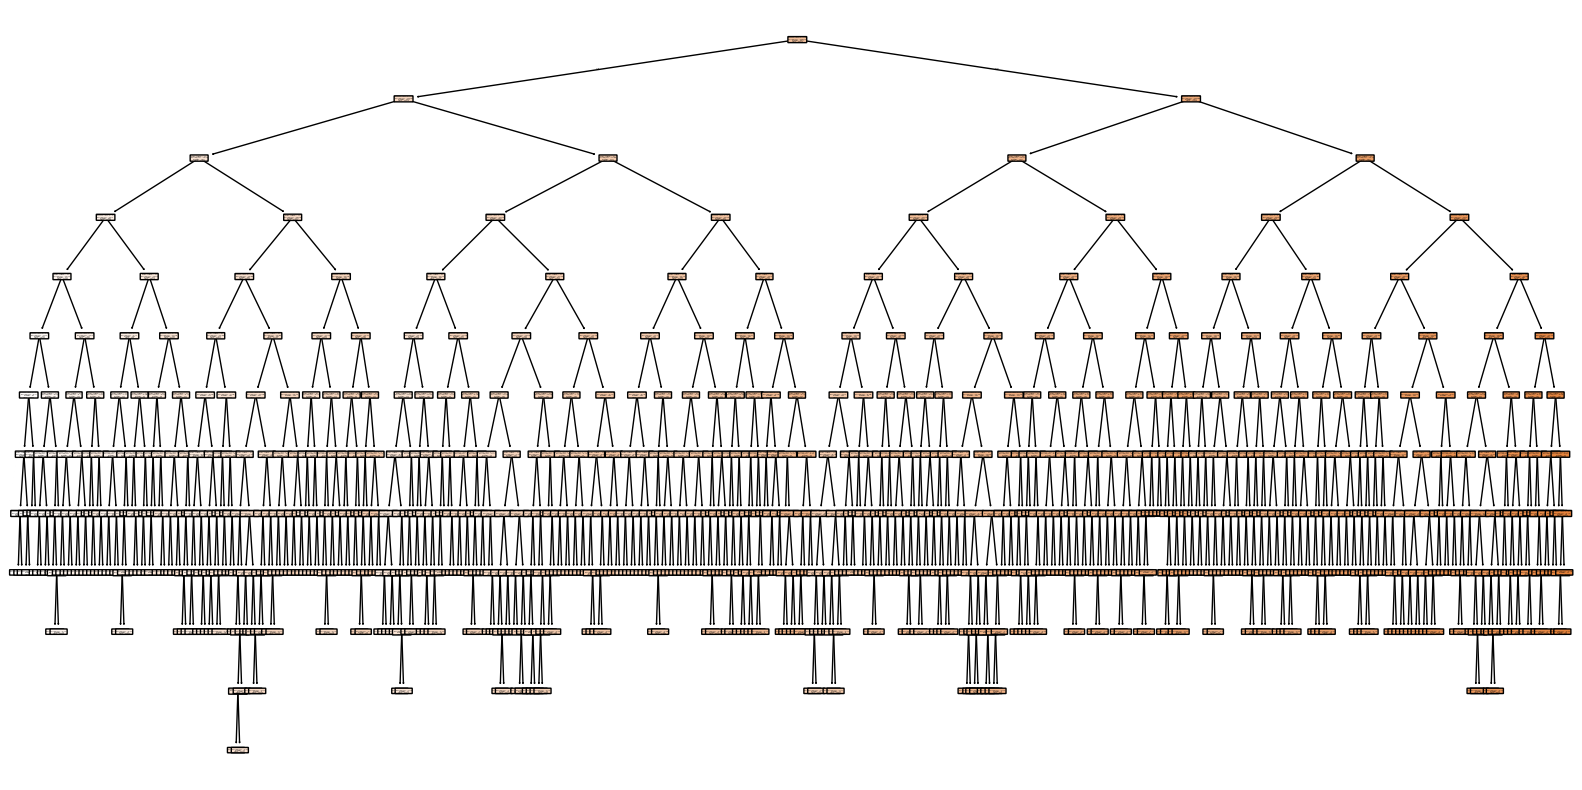

In [100]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

tree.plot_tree(
    clfdt,                      # your trained DecisionTreeClassifier/Regressor
    feature_names=x.columns,    # or list of feature names
    filled=True,
    rounded=True
)

plt.show()

3. Random Forest

In [101]:
from sklearn.ensemble import RandomForestRegressor
clfrf = RandomForestRegressor(n_estimators=500,max_depth=20)
clfrf.fit(x_train,y_train)
predictionsrf = clfrf.predict(x_test)

/Users/stark/Documents/Programming/Machine Learning/Student-score-prediction/venv/lib/python3.13/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Evaluations

In [102]:
from sklearn.metrics import mean_absolute_error,root_mean_squared_error
maedt = mean_absolute_error(y_test,predictionsdt)
rmsedt = root_mean_squared_error(y_test,predictionsdt)
print("Mae of DT = ",maedt)
print("RMSE of DT = ",rmsedt)
maelr = mean_absolute_error(y_test,predictionslr)
rmselr = root_mean_squared_error(y_test,predictionslr)
print("Mae of Linear Regex = ",maelr)
print("RMSE of Linear Regex = ",rmselr)
maerf = mean_absolute_error(y_test,predictionsrf)
rmserf = root_mean_squared_error(y_test,predictionsrf)
print("Mae of RF = ",maerf)
print("RMSE of RF = ",rmserf)

Mae of DT =  1.8708518263969334
RMSE of DT =  2.3501300407226964
Mae of Linear Regex =  1.8269025376295671
RMSE of Linear Regex =  2.289524227116086
Mae of RF =  1.8713857806483103
RMSE of RF =  2.350760266720268


Saving the Model

In [103]:
import pickle
pickle.dump(clflr,open("../model/model.pkl","wb"))